In [61]:
import pandas as pd

In [62]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


> fruits는 35개의 apple과 14의 berry로 정렬 및 구성

In [63]:
fruits.iloc[:35,:]

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple
5,29.7,450.0,apple
6,29.7,500.0,apple
7,30.0,390.0,apple
8,30.0,450.0,apple
9,30.7,500.0,apple


In [64]:
# apple 정보 불러오기
apple = fruits.iloc[:35,:]
apple.tail()

,length,weight,name
30,38.5,920.0,apple
31,38.5,955.0,apple
32,39.5,925.0,apple
33,41.0,975.0,apple
34,41.0,950.0,apple


In [65]:
# 산포도로 확인하기
import matplotlib.pylab as plt

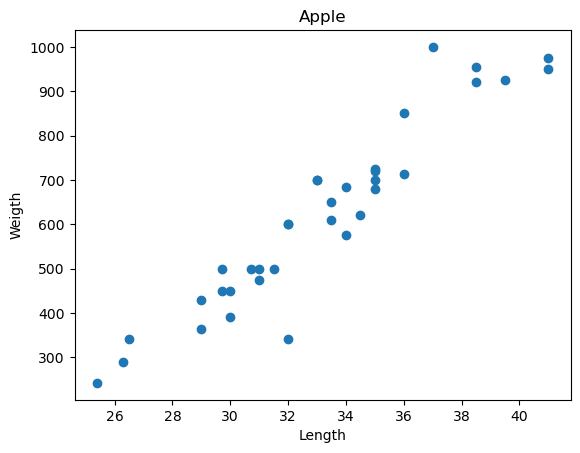

In [66]:
plt.scatter(
    apple.length,
    apple.weight
)

plt.xlabel("Length")
plt.ylabel("Weigth")
plt.title("Apple")
plt.show()


In [67]:
# berry 불러오기

berry = fruits.iloc[35:,:]
berry.tail()

,length,weight,name
44,12.2,12.2,berry
45,12.4,13.4,berry
46,13.0,12.2,berry
47,14.3,19.7,berry
48,15.0,19.9,berry


Text(0.5, 1.0, 'Berry')

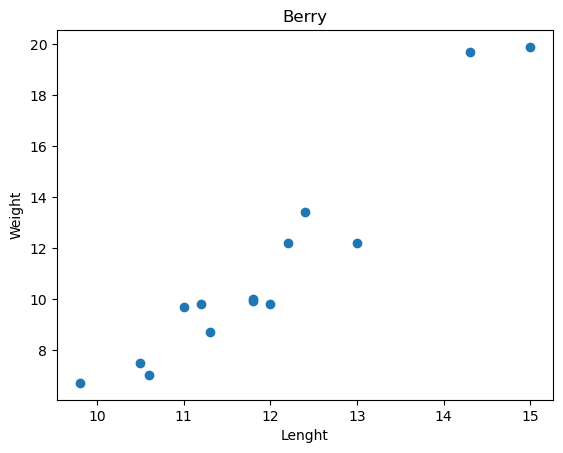

In [68]:
plt.scatter(
    berry.length,
    berry.weight
)

plt.xlabel("Lenght")
plt.ylabel("Weight")
plt.title("Berry")

In [69]:
# berry 불러오기 _선생님 정답

berry = fruits.iloc[35:,:]
berry.head()

,length,weight,name
35,9.8,6.7,berry
36,10.5,7.5,berry
37,10.6,7.0,berry
38,11.0,9.7,berry
39,11.2,9.8,berry


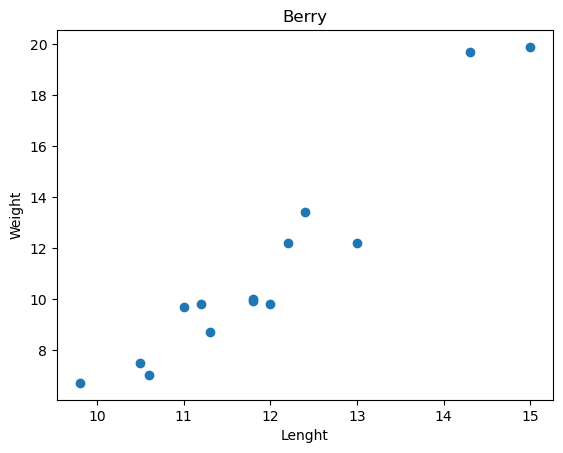

In [70]:
plt.scatter(
    berry.length,
    berry.weight
)

plt.xlabel("Lenght")
plt.ylabel("Weight")
plt.title("Berry")

plt.show()

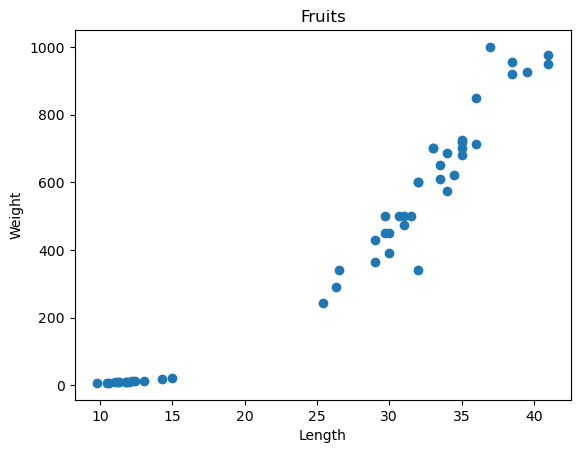

In [71]:
# fruits로 산포도
plt.scatter(
    fruits.length,
    fruits.weight
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Fruits")

plt.show()

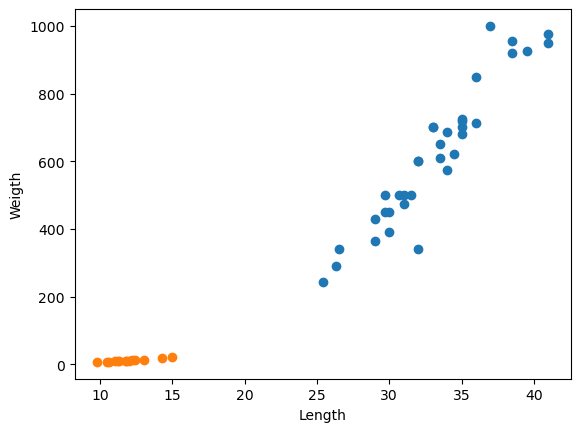

In [72]:
# 2개의 Dataset을 산포도로 한꺼번에 비교하기

plt.scatter(
    apple.length,
    apple.weight
)

plt.scatter(
    berry.length,
    berry.weight
)
plt.xlabel("Length")
plt.ylabel("Weigth")


plt.show()

---
### 머신러닝을 위한 데이터 준비
- Feature Data 와 Target Data의 분리

In [73]:
# Feature Data

# freatureColumns = ['lenght', 'weight']
# fruitsData = [freatureColumns]
fruitsData = fruits.loc[:,['length','weight']]
fruitsData.head()


,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [74]:
# Target Data

fruitsTarget = fruits.name
fruitsTarget[:5]

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [75]:
fruitsTarget.info()

<class 'pandas.core.series.Series'>
RangeIndex: 49 entries, 0 to 48
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
49 non-null     object
dtypes: object(1)
memory usage: 524.0+ bytes


### 최근접 이웃(kNN:k  Nearest Neighbors) 분류 알고리즘 사용 

In [76]:
from sklearn.neighbors import KNeighborsClassifier

In [77]:
# Model 생성

kn = KNeighborsClassifier() # n_neighbors=5 <= default 

In [78]:
# 학습 시키기

kn.fit(fruitsData,fruitsTarget)

KNeighborsClassifier()

In [79]:
# 정확도

kn.score(fruitsData, fruitsTarget)

1.0

In [80]:
# 워닝 제거
import warnings
warnings.filterwarnings('ignore')

In [81]:
# 예측해 보기
# 길이가 30cm이고 무게가 600g인 것은 무엇인가?
# 내가 한 정답
kn.predict([[30, 600]])

array(['apple'], dtype=object)

In [82]:
# 예측해 보기
# 길이가 30cm이고 무게가 600g인 것은 무엇인가?
# 선생님 정답 // 2차원데이터라 대괄호 두개 -> 내가 한 정답에 글자만 줄거라 뒤에 붙인 것임
kn.predict([[30, 600]])[0]

'apple'

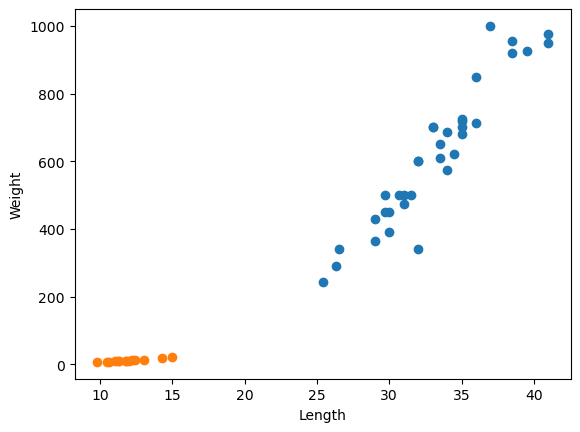

In [83]:
# 산포도 예측 범위 확인하기

plt.scatter(
    apple.length,
    apple.weight
)


plt.scatter(
    berry.length,
    berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()